# VKC-Turno repo SOC method, applied to EVE HPPC cell 0005

Faithful port of [`utils/soc_utils.py`](https://github.com/VKC-Turno/HPPC-post-processing/blob/master/utils/soc_utils.py) `add_state_of_charge`. The repo's algorithm:

1. Group by `(Cycle No, Step No)` — SOC is reset every step.
2. `SOC_step = |Capacity(Ah)| / max_cap` — repo hardcodes `max_cap = 150` (CALB nominal).
3. For `CC_DChg` steps, invert to `1 - SOC` so the trace counts 100 → 0 % within the step.
4. Multiply by 100 for percent.

This is a **step-relative coordinate**, not a cell-state SOC; it resets at every step boundary. The plots below render it the same way the repo's `soc_voltage_plots.py` does — one panel per step type — for the EVE HPPC trace of cell 0005.

In [1]:
from __future__ import annotations
import os, sys
from pathlib import Path

ROOT = Path.cwd()
if (ROOT.parent / 'CLAUDE.md').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'matplotlib'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_test

CELL = '0005'
print('Project root:', ROOT)
print('Target cell :', CELL)

Project root: /home/hj/Desktop/PINNs
Target cell : 0005


/home/hj/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load EVE HPPC trace and reshape to the repo's expected schema

Our `data_loader.load_test` returns lowercase columns and *no* `Step No`. The VKC repo expects `Cycle No`, `Step No`, `Step name`, `Capacity(Ah)`, `volt(V)`, `Current(A)`. We add a synthetic `Step No` by cumulative-summing `step_name` transitions, then rename to match.

In [2]:
df_raw = load_test('HPPC', cell_id=CELL).sort_values('time').reset_index(drop=True)
df_raw['Step No'] = (df_raw['step_name'] != df_raw['step_name'].shift()).cumsum()

df = df_raw.rename(columns={
    'cycle':        'Cycle No',
    'step_name':    'Step name',
    'absolute_time':'Absolute time',
    'voltage':      'volt(V)',
    'current':      'Current(A)',
    'capacity':     'Capacity(Ah)',
})[['Cycle No', 'Step No', 'Step name', 'Absolute time',
    'volt(V)', 'Current(A)', 'Capacity(Ah)']]

print(f'rows: {len(df):,}    cycles: {df["Cycle No"].nunique()}    distinct (cycle, step): {df.groupby(["Cycle No", "Step No"]).ngroups}')
print('\nstep_name counts:')
print(df['Step name'].value_counts())
print('\nfirst 5 (cycle, step, step name) groups:')
print(df.groupby(['Cycle No', 'Step No', 'Step name'], sort=False).size().head(8))

rows: 51,254    cycles: 1    distinct (cycle, step): 48

step_name counts:
Step name
Rest        36410
CCCV_Chg    11164
CC_DChg      3581
CC_Chg         99
Name: count, dtype: int64

first 5 (cycle, step, step name) groups:
Cycle No  Step No  Step name
1         1        Rest            31
          2        CCCV_Chg     11164
          3        Rest          3601
          4        CC_DChg         31
          5        Rest            41
          6        CC_Chg          11
          7        CC_DChg          8
          8        Rest          3601
dtype: int64


## 2. Port of `add_state_of_charge` — verbatim repo logic

The function below is line-for-line equivalent to [`utils/soc_utils.py`](https://github.com/VKC-Turno/blob/master/utils/soc_utils.py). The `max_cap = 150` hardcode is preserved; we also expose a `max_cap` kwarg so we can swap in the EVE LF105 nominal (105 Ah) to see what changes.

In [3]:
from typing import Iterable

REQUIRED_COLUMNS = (
    'Cycle No', 'Step No', 'Step name', 'Absolute time',
    'volt(V)', 'Current(A)', 'Capacity(Ah)',
)
OUTPUT_COLUMNS = ('Cycle No', 'Step No', 'Step name', 'Absolute time', 'soc')

def _check_columns(df, required):
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

def add_state_of_charge(df: pd.DataFrame, max_cap: float = 150.0) -> pd.DataFrame:
    """Port of utils/soc_utils.py::add_state_of_charge.
    SOC_step = |Capacity(Ah)| / max_cap, inverted for CC_DChg, scaled to percent.
    """
    _check_columns(df, REQUIRED_COLUMNS)
    working = df.copy()
    working['Capacity(Ah)'] = pd.to_numeric(working['Capacity(Ah)'], errors='coerce').fillna(0.0)
    soc_values = np.zeros(len(working), dtype=float)

    grouped = working.groupby(['Cycle No', 'Step No'], sort=False)
    for _, group in grouped:
        idx = group.index.to_numpy()
        if idx.size == 0:
            continue
        cap = group['Capacity(Ah)'].abs().to_numpy()
        if max_cap == 0.0:
            soc = np.zeros_like(cap)
        else:
            soc = cap / max_cap
        step_name = str(group['Step name'].iloc[0]).strip().lower()
        if step_name == 'cc_dchg':
            soc = 1.0 - soc
        soc_values[idx] = soc * 100.0

    working['soc'] = soc_values
    return working

# Two passes: repo's hardcoded 150 Ah AND EVE LF105 nominal 105 Ah
df_soc_150 = add_state_of_charge(df, max_cap=150.0)
df_soc_105 = add_state_of_charge(df, max_cap=105.0)

print('with max_cap = 150 Ah (repo default):')
print(df_soc_150.groupby('Step name')['soc'].agg(['min', 'max', 'mean']).round(2))
print('\nwith max_cap = 105 Ah (EVE LF105 nominal):')
print(df_soc_105.groupby('Step name')['soc'].agg(['min', 'max', 'mean']).round(2))

with max_cap = 150 Ah (repo default):
             min     max   mean
Step name                      
CCCV_Chg    0.00   69.38  36.11
CC_Chg      0.00    0.07   0.04
CC_DChg    78.75  100.00  90.26
Rest        0.00    0.00   0.00

with max_cap = 105 Ah (EVE LF105 nominal):
             min     max   mean
Step name                      
CCCV_Chg    0.00   99.11  51.58
CC_Chg      0.00    0.10   0.05
CC_DChg    69.65  100.00  86.09
Rest        0.00    0.00   0.00


## 3. SOC vs Voltage — one panel per step type

Same panel layout as the repo's [`soc_voltage_plots.py`](https://github.com/VKC-Turno/HPPC-post-processing/blob/master/utils/soc_voltage_plots.py). For each panel, every individual `Step No` instance (each repetition of that step type in the file) is one coloured line. Rest steps are omitted, matching the repo.

Each panel's X axis is the **step-relative** SOC: 0 → 100 % for charge steps, 100 → 0 % for `CC_DChg`. The panel labelled "Other steps" catches any step name not in the repo's `{CC_Chg, CCCV_Chg, CC_DChg}` set (e.g. for our EVE HPPC file, this would include probe-pulse blocks that the protocol calls something else).

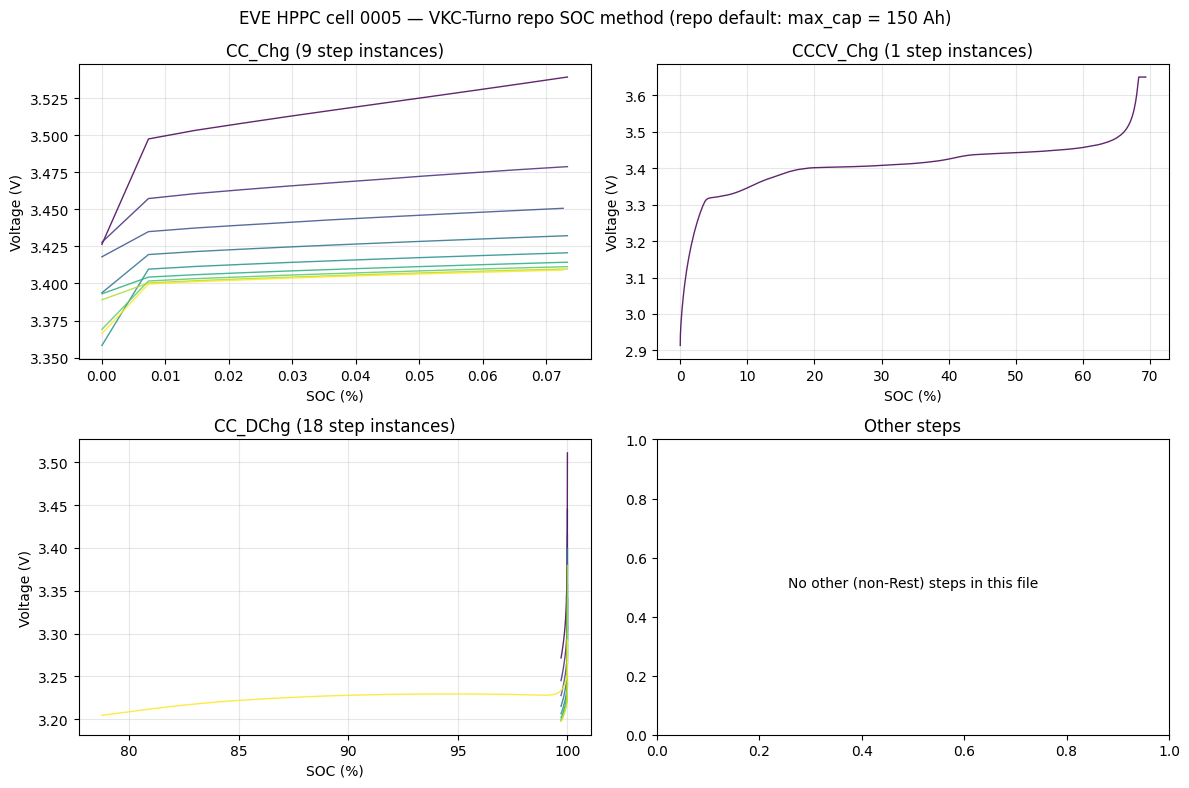

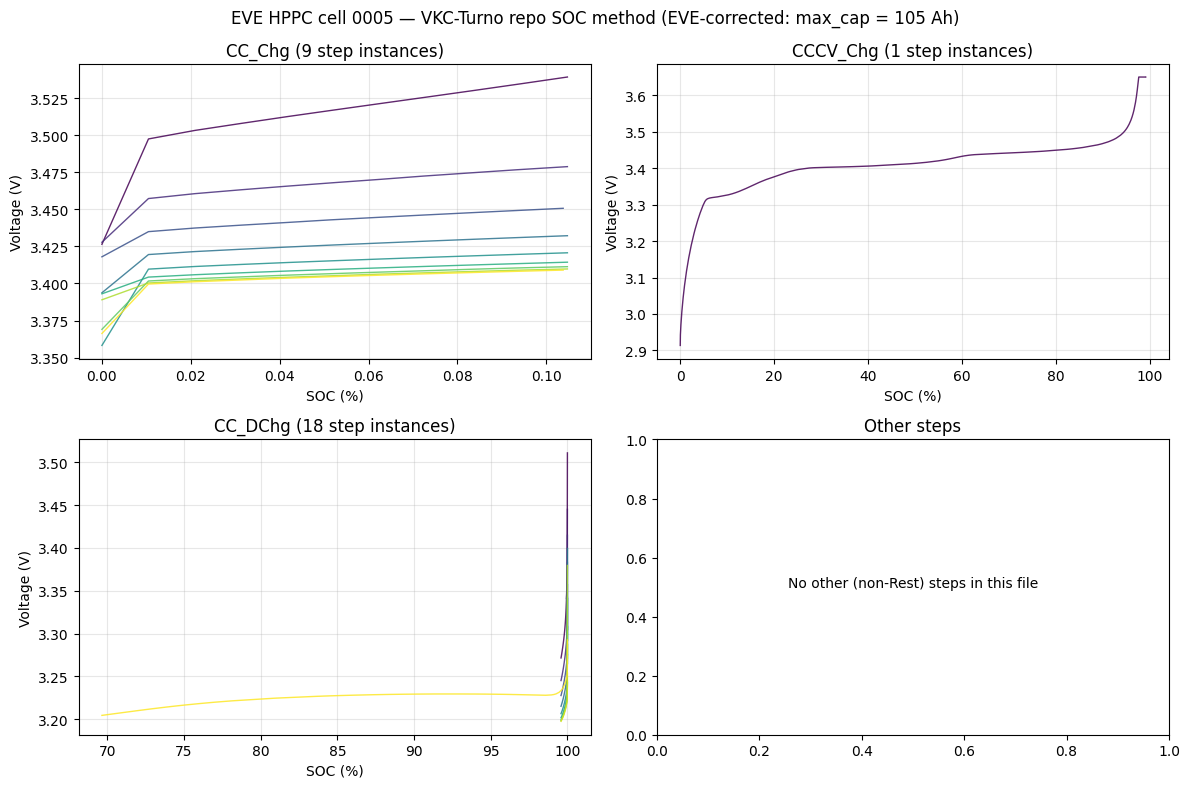

In [4]:
def plot_step_subplots(df_soc: pd.DataFrame, title_suffix: str):
    repo_steps = ['CC_Chg', 'CCCV_Chg', 'CC_DChg']
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, sname in zip(axes[:3], repo_steps):
        sub = df_soc[df_soc['Step name'] == sname]
        n_instances = sub['Step No'].nunique()
        if sub.empty:
            ax.text(0.5, 0.5, f'{sname}: no data', transform=ax.transAxes, ha='center')
            ax.set(title=sname)
            continue
        step_ids = sorted(sub['Step No'].unique())
        cmap = plt.cm.viridis(np.linspace(0, 1, max(len(step_ids), 2)))
        for c, sid in zip(cmap, step_ids):
            g = sub[sub['Step No'] == sid].sort_values('soc')
            ax.plot(g['soc'], g['volt(V)'], lw=1.0, color=c, alpha=0.85)
        ax.set(xlabel='SOC (%)', ylabel='Voltage (V)',
               title=f'{sname} ({n_instances} step instances)')
        ax.grid(True, alpha=0.3)

    # 4th panel: anything not in the repo's set (probe-pulse blocks, etc.)
    ax = axes[3]
    sub_other = df_soc[~df_soc['Step name'].isin(repo_steps + ['Rest'])]
    if sub_other.empty:
        ax.text(0.5, 0.5, 'No other (non-Rest) steps in this file',
                transform=ax.transAxes, ha='center')
        ax.set(title='Other steps')
    else:
        for sname, g in sub_other.groupby('Step name'):
            ax.plot(g['soc'], g['volt(V)'], 'o', ms=2, alpha=0.5, label=sname)
        ax.set(xlabel='SOC (%)', ylabel='Voltage (V)', title='Other steps')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'EVE HPPC cell {CELL} — VKC-Turno repo SOC method ({title_suffix})', fontsize=12)
    fig.tight_layout()
    plt.show()

plot_step_subplots(df_soc_150, 'repo default: max_cap = 150 Ah')
plot_step_subplots(df_soc_105, 'EVE-corrected: max_cap = 105 Ah')

## 4. Per-step-instance overlay for `CC_DChg` — the probe pulses

The HPPC discharge probes are short (~30 s, 52.5 A → ~0.44 Ah each) and each one is its own `CC_DChg` Step No. Under the repo's method, each probe starts at SOC = 100 % and ends near 100 % (because 0.44 / 150 ≈ 0.3 %). To make the structure visible we re-plot the discharge sub-panel with each probe Step No coloured by Step No index, so you can see how the repo's step-relative coordinate places every probe at the very top of the X axis.

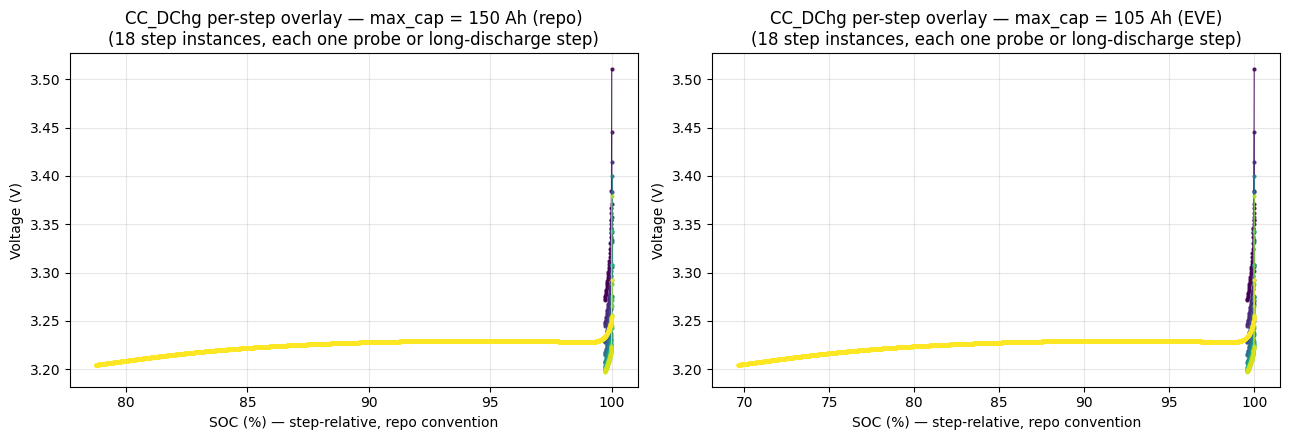

,Step No,n_rows,V_start,V_end,Cap_max_Ah,SOC_start_repo_105,SOC_end_repo_105
0,4,31,3.511,3.272,0.437,100.0,99.584
1,7,8,3.445,3.341,0.062,100.0,99.941
2,9,31,3.415,3.245,0.438,100.0,99.583
3,12,2,3.357,3.333,0.001,100.0,99.999
4,14,31,3.383,3.228,0.438,100.0,99.583
5,17,2,3.342,3.306,0.000,100.0,100.000
6,19,31,3.332,3.215,0.438,100.0,99.583
7,22,2,3.400,3.293,0.000,100.0,100.000
8,24,31,3.275,3.207,0.438,100.0,99.583
9,27,2,3.308,3.275,0.001,100.0,99.999


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, df_soc, lab in [(ax1, df_soc_150, 'max_cap = 150 Ah (repo)'),
                          (ax2, df_soc_105, 'max_cap = 105 Ah (EVE)')]:
    sub = df_soc[df_soc['Step name'] == 'CC_DChg']
    step_ids = sorted(sub['Step No'].unique())
    cmap = plt.cm.viridis(np.linspace(0, 1, max(len(step_ids), 2)))
    for c, sid in zip(cmap, step_ids):
        g = sub[sub['Step No'] == sid].sort_values('Absolute time')
        ax.plot(g['soc'], g['volt(V)'], '-o', ms=2, lw=0.8, color=c, alpha=0.85)
    ax.set(xlabel='SOC (%) — step-relative, repo convention',
           ylabel='Voltage (V)',
           title=f'CC_DChg per-step overlay — {lab}\n({len(step_ids)} step instances, each one probe or long-discharge step)')
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# Numeric summary: per CC_DChg Step No, show SOC start/end and dQ
summary = []
sub = df_soc_105[df_soc_105['Step name'] == 'CC_DChg']
for sid, g in sub.groupby('Step No'):
    summary.append({
        'Step No': int(sid),
        'n_rows': len(g),
        'V_start': float(g['volt(V)'].iloc[0]),
        'V_end':   float(g['volt(V)'].iloc[-1]),
        'Cap_max_Ah': float(g['Capacity(Ah)'].abs().max()),
        'SOC_start_repo_105': float(g['soc'].iloc[0]),
        'SOC_end_repo_105':   float(g['soc'].iloc[-1]),
    })
pd.DataFrame(summary).round(3)

## 5. What the repo method actually shows for this file

- The repo's `soc` column is **not a cell-state SOC**. It is reset at every step boundary, normalised against a fixed denominator (150 Ah in the repo, 105 Ah corrected for EVE LF105).
- Each `CC_DChg` step in the HPPC file gets its own 100 → (100 − dQ/max_cap·100) %  trajectory. For the short probe pulses (dQ ≈ 0.44 Ah) this collapses to a near-vertical drop at SOC ≈ 100 %; for the one long discharge step (~30–45 Ah) it sweeps a visible 100 → ~70 % wedge.
- Replacing 150 Ah with the EVE nominal 105 Ah stretches the X axis but does not change the qualitative picture or fix the step-reset behaviour.
- This is fine for the repo's stated purpose (visualising the V(Q) shape inside a single CCCV charge), but it cannot answer "what was the cell SOC at probe pulse k vs k+1?" — which is the question the lab report's HPPC SOC-band claim depends on. The OCV-anchored coulomb count in [`notebooks/03_raw_signal_verification.ipynb`](03_raw_signal_verification.ipynb) is the right tool for that question.